In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch

%matplotlib inline
torch.manual_seed(0)
np.random.seed(0)


## Phase 1 -- Ordinary PINN baseline

Before tackling the memory-integral equation, we first solve the plain
diffusion equation `dc/dt = D * c_xx` with a standard PINN. This is where
collocation points, automatic differentiation, and the physics/IC/BC
losses are first exercised.

[Baseline] epoch     0 | loss 8.752e-01 | physics 1.624e-03 | ic 8.597e-02 | bc 1.386e-03
[Baseline] epoch   500 | loss 1.157e-01 | physics 2.479e-02 | ic 7.869e-03 | bc 1.221e-03
[Baseline] epoch  1000 | loss 8.290e-03 | physics 4.578e-03 | ic 3.656e-04 | bc 5.664e-06
[Baseline] epoch  1500 | loss 2.255e-03 | physics 1.523e-03 | ic 6.763e-05 | bc 5.556e-06
[Baseline] epoch  2000 | loss 1.242e-03 | physics 9.073e-04 | ic 2.995e-05 | bc 3.523e-06
[Baseline] epoch  2500 | loss 8.108e-04 | physics 6.095e-04 | ic 1.767e-05 | bc 2.457e-06
[Baseline] MSE=6.198e-06 | relative L2=1.193e-02
Baseline relative L2 error: 0.0119


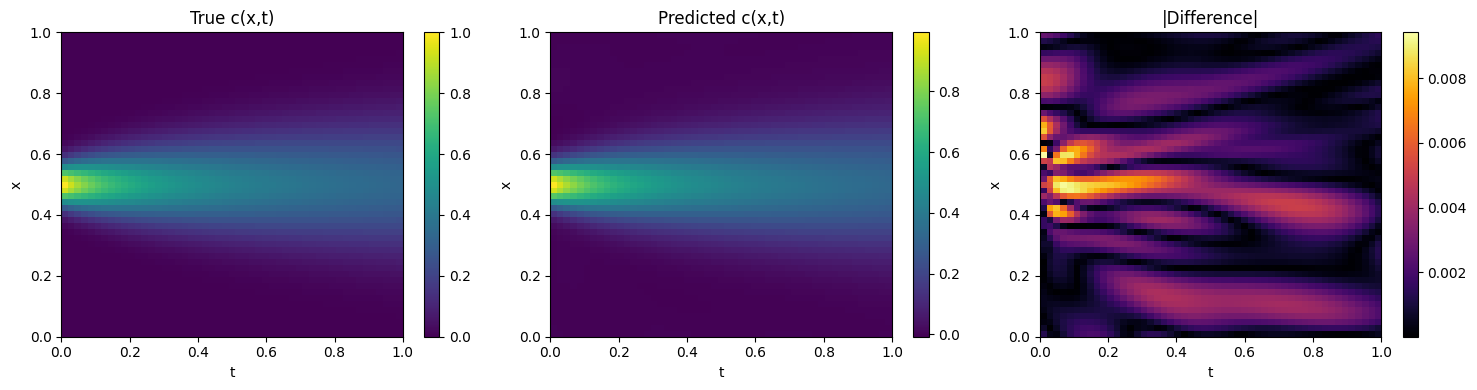

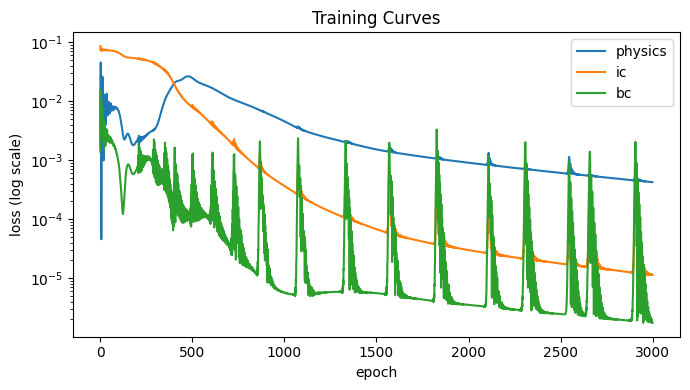

In [3]:
from training.train_baseline import run_baseline

baseline_results, baseline_pinn = run_baseline(
    D=0.01, Nx=51, Nt=51, n_colloc=1500, epochs=3000, print_every=500,
    out_dir='../results'
)
print(f"Baseline relative L2 error: {baseline_results['relative_l2']:.4f}")


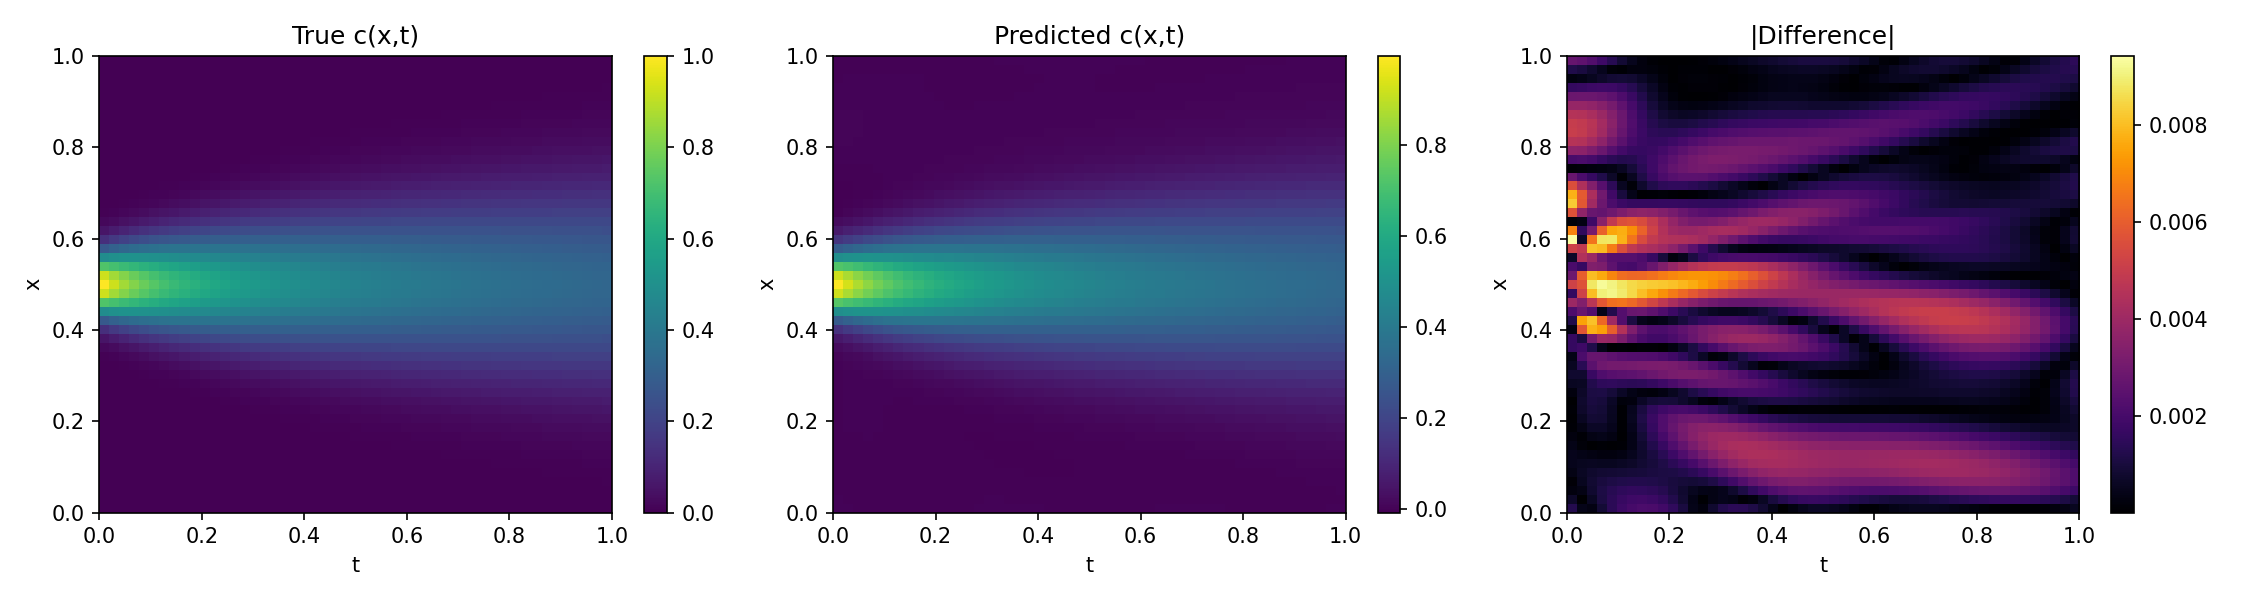

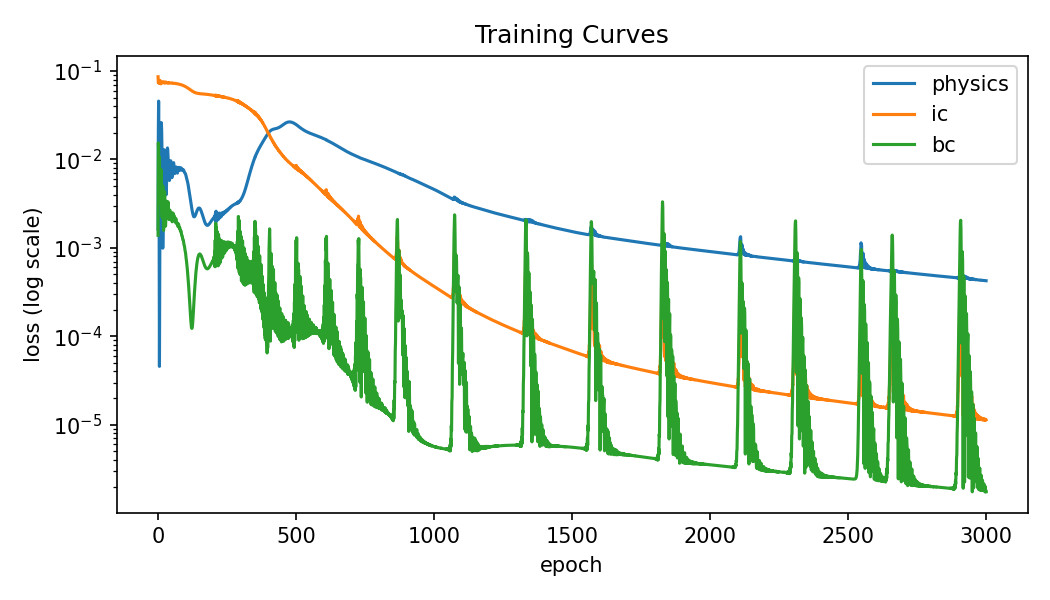

In [1]:
from IPython.display import Image, display
display(Image('../results/baseline_heatmaps.png'))
display(Image('../results/baseline_loss.png'))


## Phases 2-12 -- The memory PINN

The pipeline for the full non-Markovian model is implemented in
`data/generate_data.py` (FD ground truth with a known memory kernel),
`models/pinn.py` and `models/kernel_network.py` (the two networks),
`physics/quadrature.py` (trapezoidal neural quadrature -- Phase 6),
`physics/diffusion.py` (the residual, Phase 7), `physics/losses.py`
(IC/BC/data losses, Phases 8-11), and `training/trainer.py` /
`training/train.py` (the training loop, Phase 12).

The helper below, `run_experiment(...)`, runs one full experiment: generate
data -> build models -> train -> evaluate -> plot.

In [3]:
from training.train import run_experiment

# Demo-scale settings (fast). Increase Nx, Nt, epochs for higher accuracy.
DEMO_KW = dict(Nx=21, Nt=21, epochs=1000, print_every=500, out_dir='../results')


ModuleNotFoundError: No module named 'training'

## Experiment 1 -- Known exponential kernel

Here the true kernel `K(t) = exp(-t)` is *fixed*, not learned. Only the
solution network `c(x,t)` is optimized. This validates that the memory
residual and trapezoidal quadrature are implemented correctly.

[Memory] epoch     0 | loss 4.091e+00 | physics 1.803e-03 | ic 1.994e-01 | bc 1.894e-01 | data 2.006e-01


[Memory] epoch   500 | loss 5.369e-01 | physics 1.194e-03 | ic 4.967e-02 | bc 9.157e-04 | data 2.985e-02


[exp1_known_kernel] c(x,t) MSE=1.127e-03 | rel L2=1.332e-01 | kernel rel L2=5.252e-08


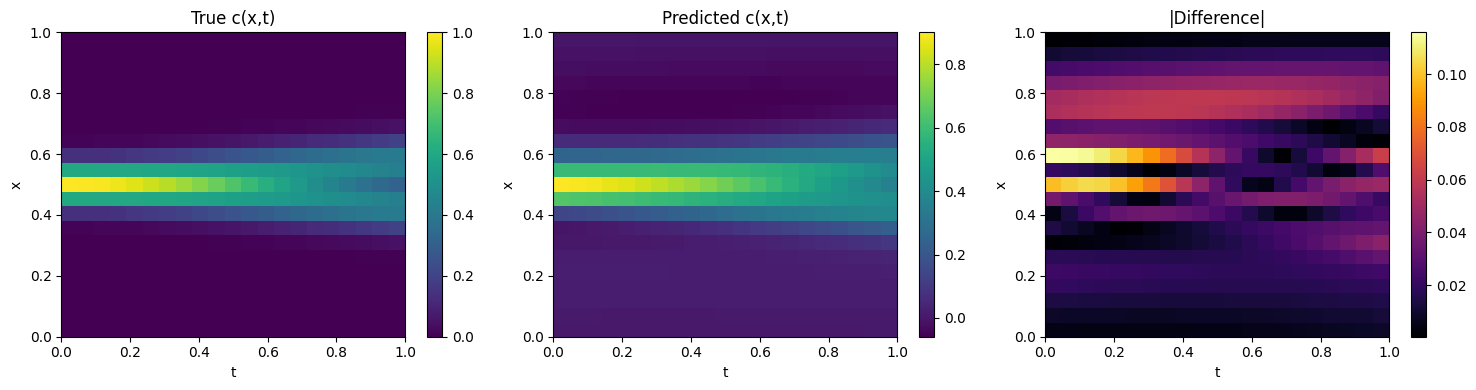

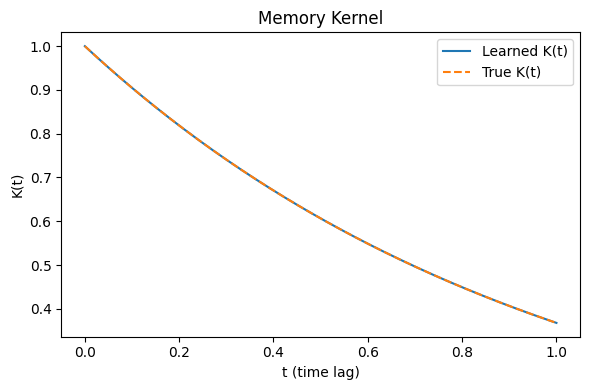

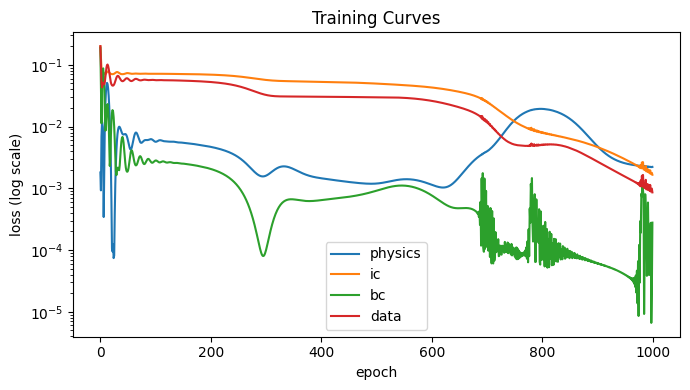

In [5]:
exp1_results, exp1_pinn, exp1_kernel = run_experiment(
    "exp1_known_kernel", learn_kernel=False, obs_fraction=0.2, noise_std=0.0,
    **DEMO_KW
)


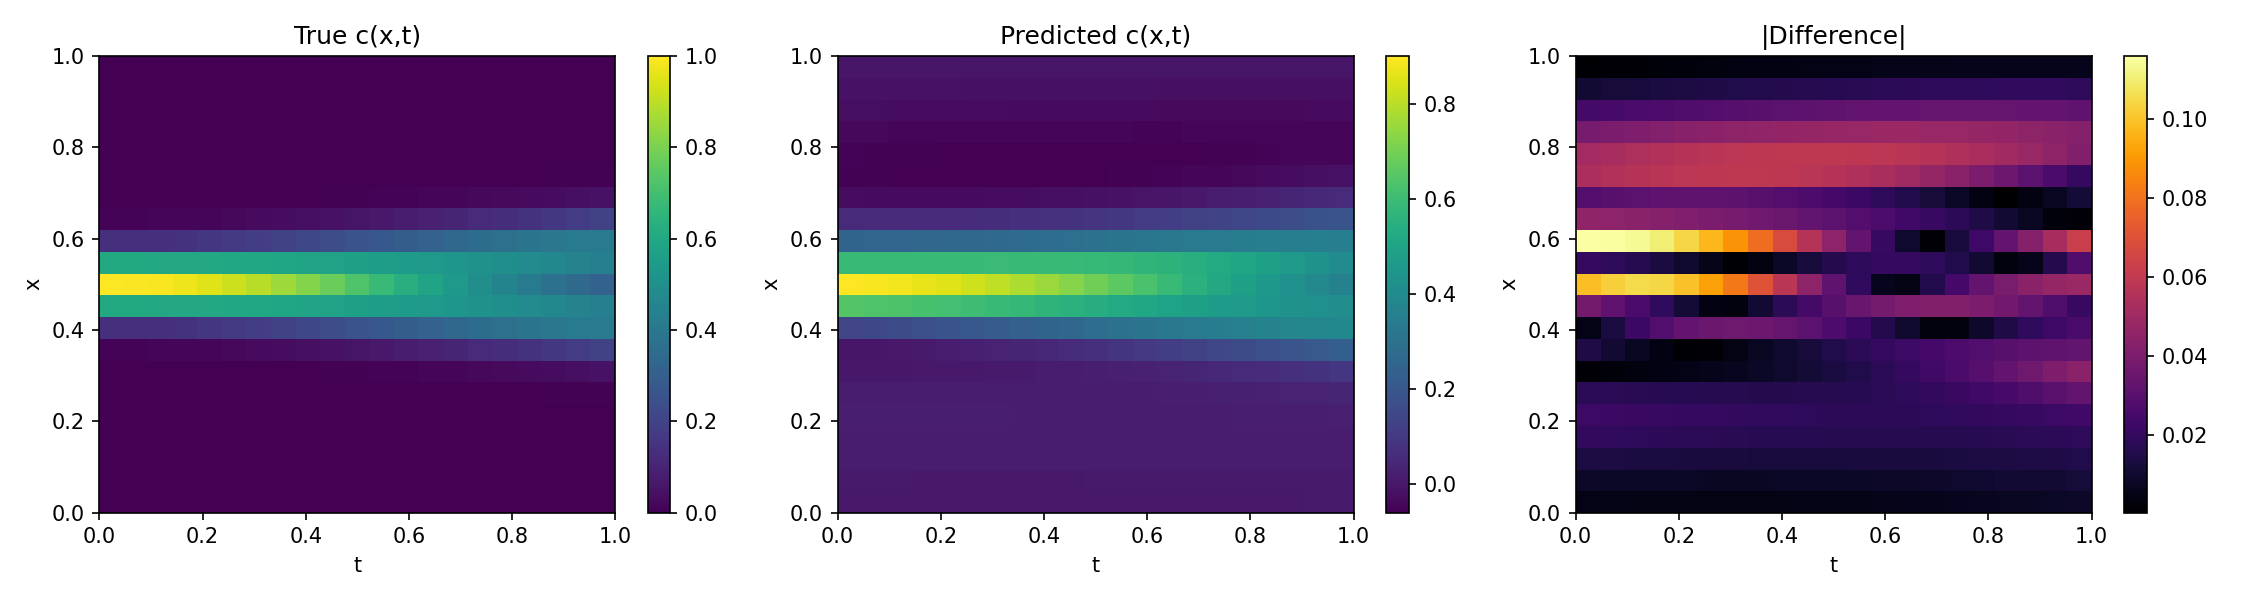

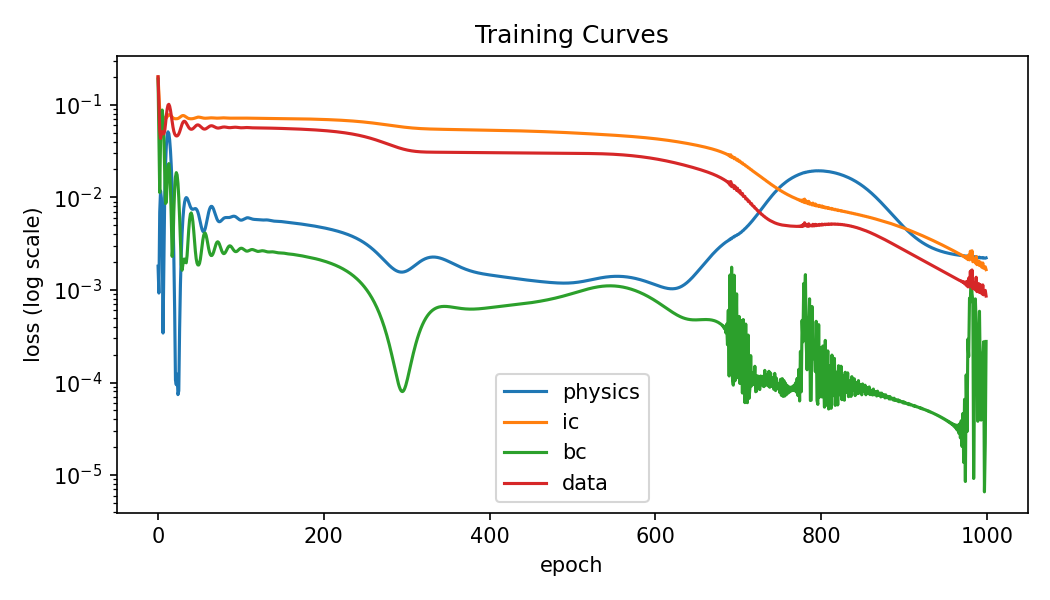

In [6]:
display(Image('../results/exp1_known_kernel_heatmaps.png'))
display(Image('../results/exp1_known_kernel_loss.png'))


## Experiment 2 -- Unknown kernel

Now the kernel is *learned* jointly with the solution, starting from a
randomly initialized `KernelNet`. We compare the learned `K(t)` against the
true `exp(-t)` kernel used to generate the data.

[Memory] epoch     0 | loss 9.063e-01 | physics 1.592e-03 | ic 8.353e-02 | bc 1.401e-03 | data 5.546e-02


[Memory] epoch   500 | loss 7.036e-02 | physics 6.532e-04 | ic 5.952e-03 | bc 1.563e-04 | data 8.625e-03


[exp2_unknown_kernel] c(x,t) MSE=1.317e-03 | rel L2=1.440e-01 | kernel rel L2=6.245e-01


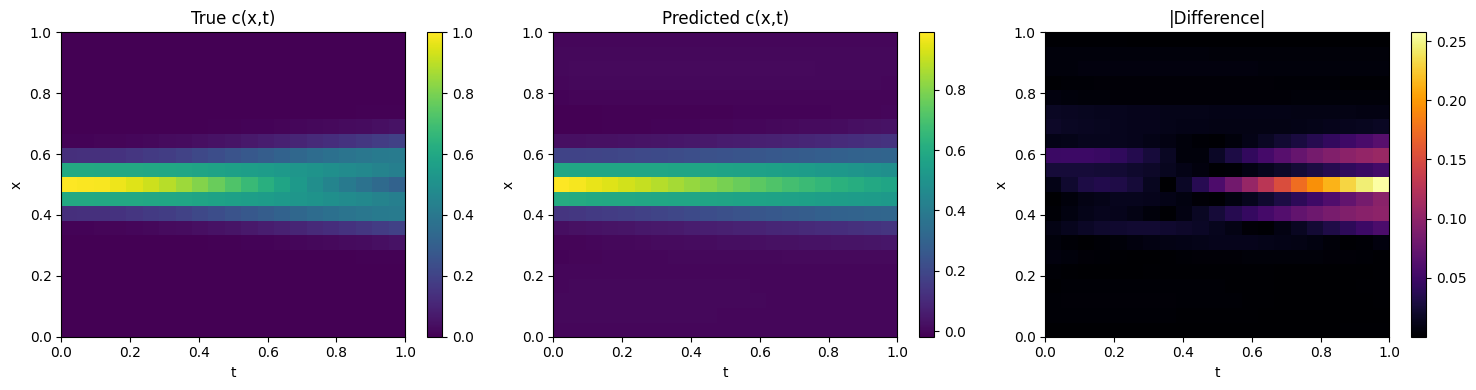

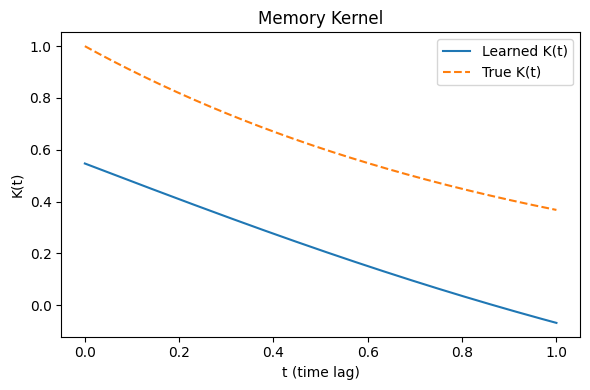

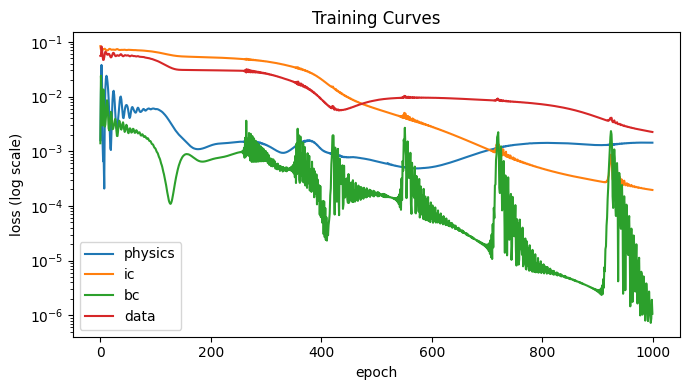

In [7]:
exp2_results, exp2_pinn, exp2_kernel = run_experiment(
    "exp2_unknown_kernel", learn_kernel=True, obs_fraction=0.2, noise_std=0.0,
    **DEMO_KW
)


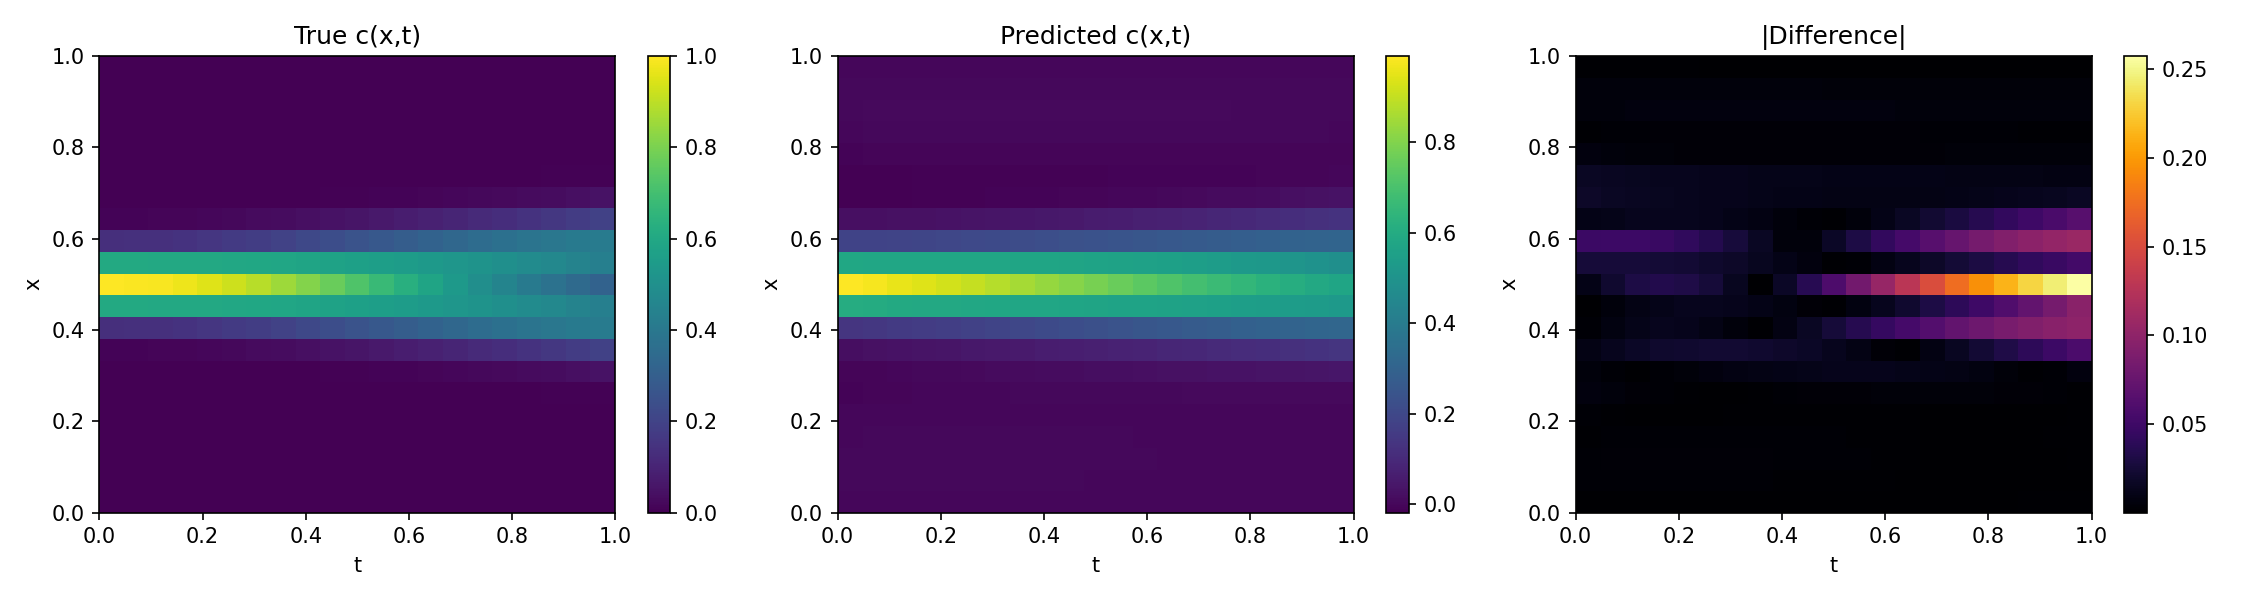

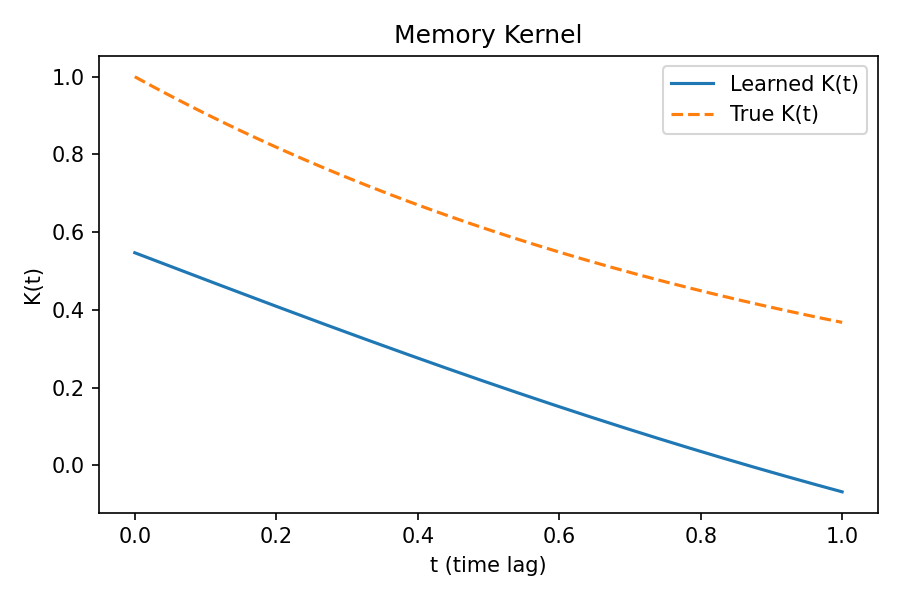

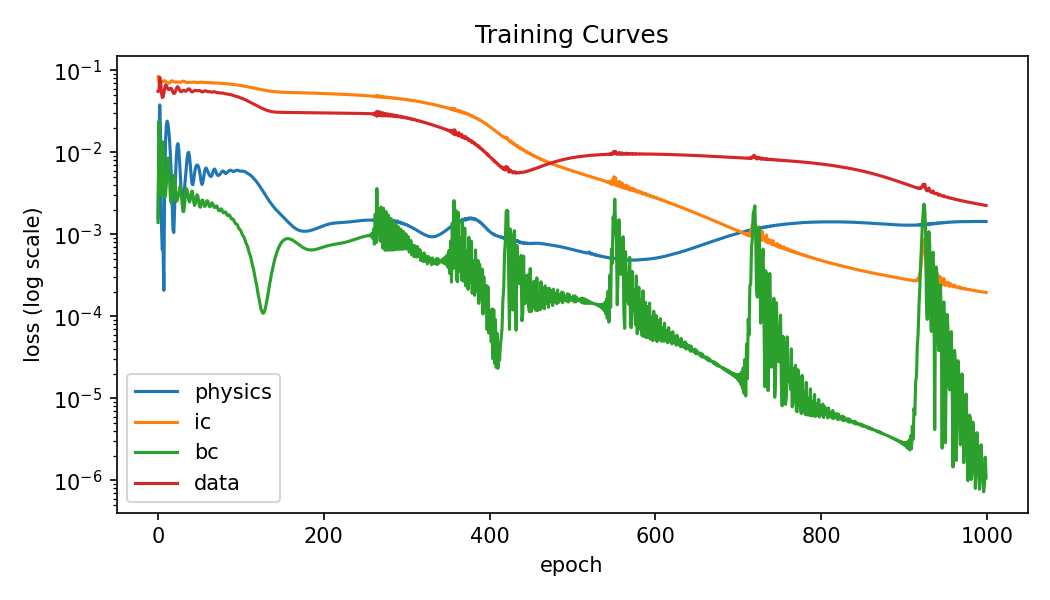

In [8]:
display(Image('../results/exp2_unknown_kernel_heatmaps.png'))
display(Image('../results/exp2_unknown_kernel_kernel.png'))
display(Image('../results/exp2_unknown_kernel_loss.png'))


## Experiment 3 -- Sparse observations

We repeat the joint (solution + kernel) learning problem while shrinking
the fraction of observed data points: 20%, 10%, 5%, 1%. We track how the
learned kernel's accuracy degrades as data becomes sparser.

[Memory] epoch     0 | loss 1.148e+00 | physics 3.460e-02 | ic 8.132e-02 | bc 2.023e-02 | data 9.821e-02


[Memory] epoch   500 | loss 7.272e-02 | physics 3.710e-04 | ic 6.217e-03 | bc 1.021e-04 | data 9.160e-03


[exp3_sparsity_20pct] c(x,t) MSE=3.015e-03 | rel L2=2.179e-01 | kernel rel L2=7.455e-01
[Memory] epoch     0 | loss 1.164e+00 | physics 1.028e-02 | ic 1.011e-01 | bc 8.242e-03 | data 6.099e-02


[Memory] epoch   500 | loss 6.406e-02 | physics 3.196e-04 | ic 5.640e-03 | bc 9.572e-05 | data 6.384e-03


[exp3_sparsity_10pct] c(x,t) MSE=2.083e-03 | rel L2=1.811e-01 | kernel rel L2=6.965e-01
[Memory] epoch     0 | loss 1.365e+00 | physics 5.334e-02 | ic 9.694e-02 | bc 2.412e-02 | data 1.006e-01


[Memory] epoch   500 | loss 1.573e-02 | physics 1.949e-04 | ic 1.374e-03 | bc 4.641e-05 | data 1.332e-03


[exp3_sparsity_5pct] c(x,t) MSE=6.262e-03 | rel L2=3.140e-01 | kernel rel L2=9.096e-01
[Memory] epoch     0 | loss 9.134e-01 | physics 6.423e-04 | ic 7.670e-02 | bc 8.651e-03 | data 5.930e-02


[Memory] epoch   500 | loss 1.458e-01 | physics 8.081e-04 | ic 1.391e-02 | bc 4.157e-05 | data 5.536e-03


[exp3_sparsity_1pct] c(x,t) MSE=4.210e-03 | rel L2=2.575e-01 | kernel rel L2=7.792e-01


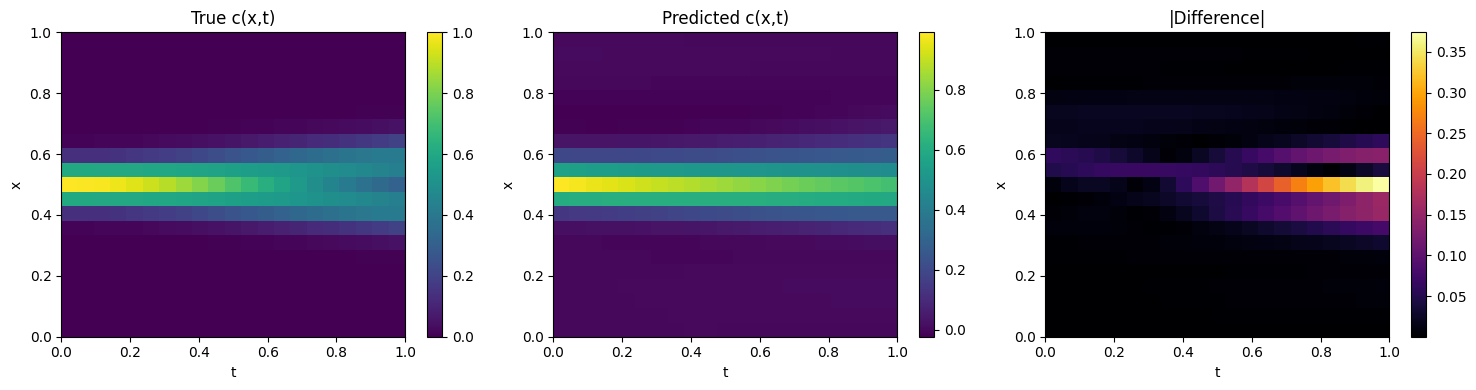

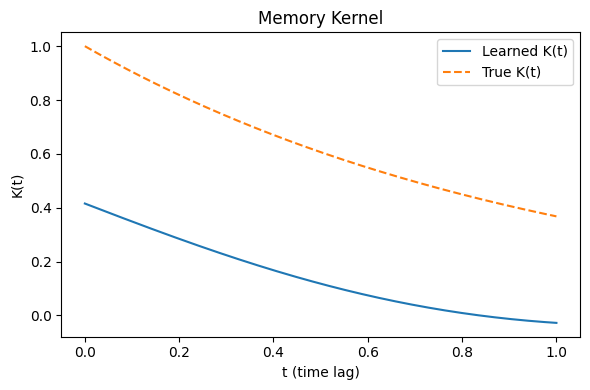

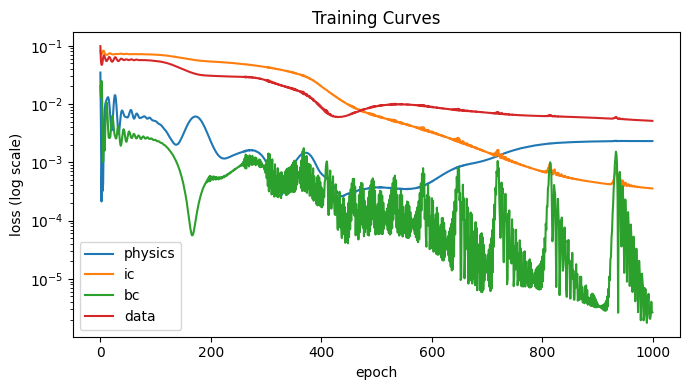

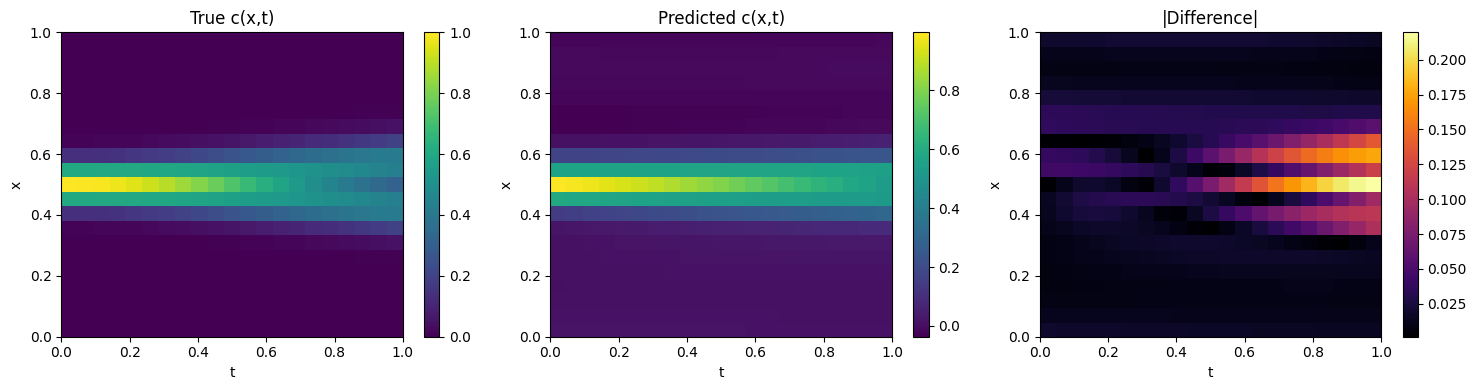

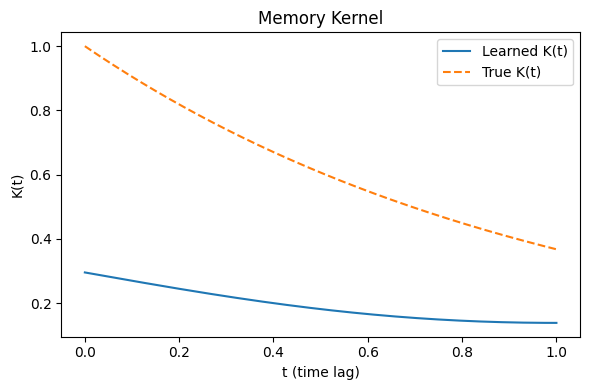

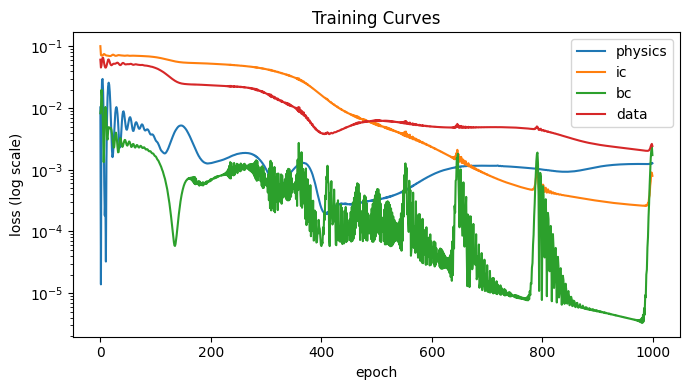

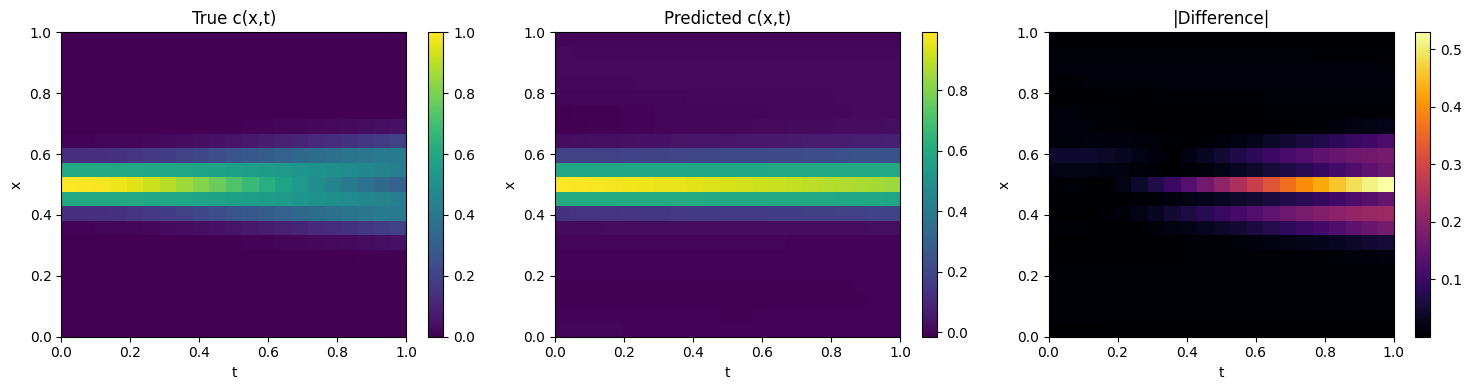

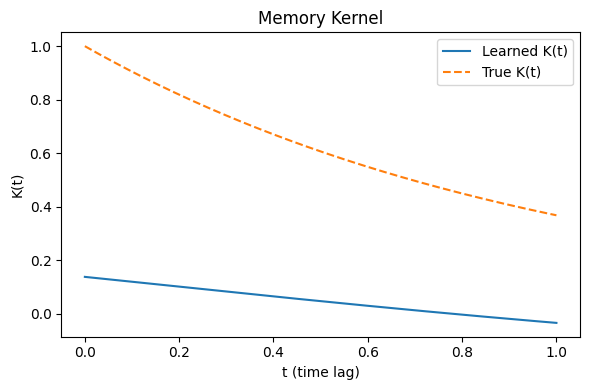

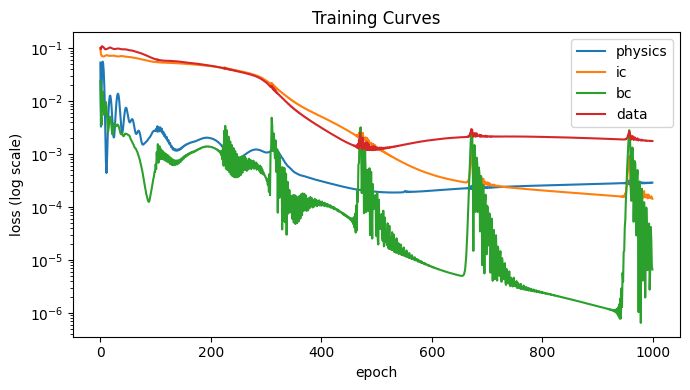

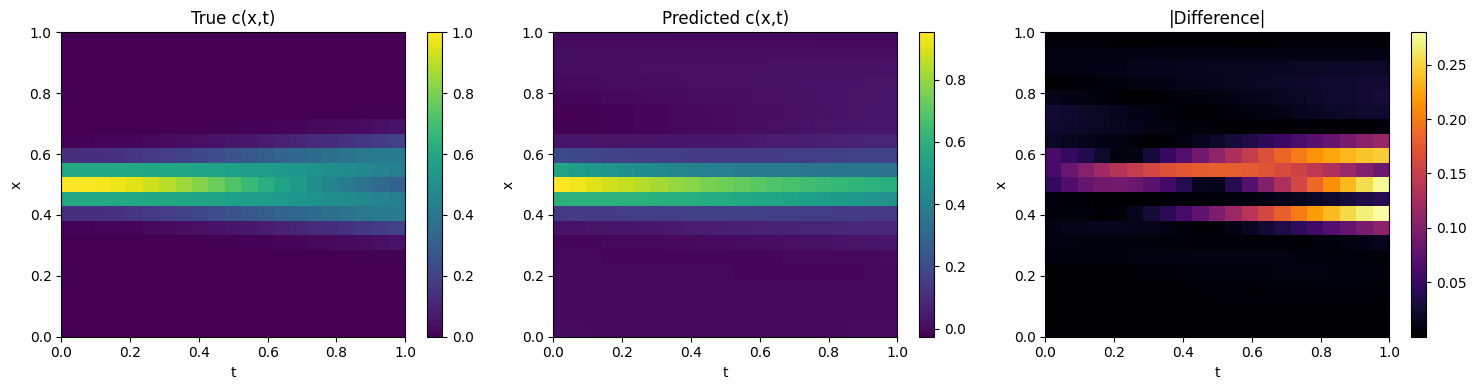

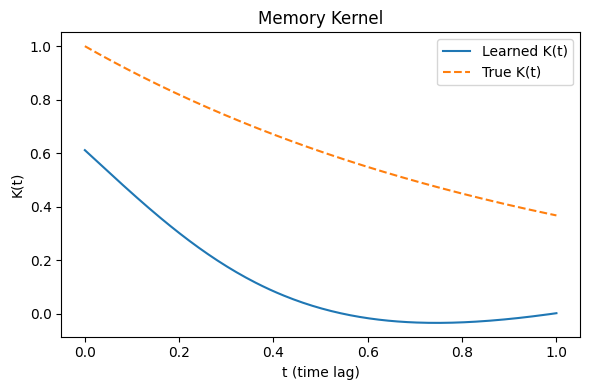

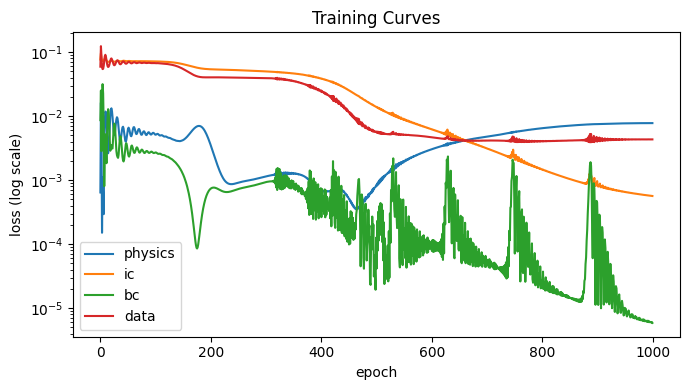

In [9]:
sparsity_levels = [0.20, 0.10, 0.05, 0.01]
exp3_results = []

for frac in sparsity_levels:
    name = f"exp3_sparsity_{int(frac*100)}pct"
    res, _, _ = run_experiment(name, learn_kernel=True, obs_fraction=frac,
                                noise_std=0.0, **DEMO_KW)
    exp3_results.append(res)


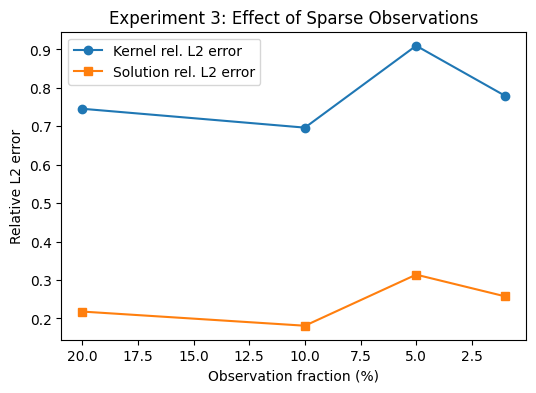

In [10]:
fracs = [r['name'] for r in exp3_results]
kernel_errs = [r['kernel_rel_l2'] for r in exp3_results]
sol_errs = [r['relative_l2'] for r in exp3_results]

fig, ax = plt.subplots(figsize=(6,4))
ax.plot([f*100 for f in sparsity_levels], kernel_errs, 'o-', label='Kernel rel. L2 error')
ax.plot([f*100 for f in sparsity_levels], sol_errs, 's-', label='Solution rel. L2 error')
ax.set_xlabel('Observation fraction (%)')
ax.set_ylabel('Relative L2 error')
ax.set_title('Experiment 3: Effect of Sparse Observations')
ax.invert_xaxis()
ax.legend()
plt.savefig('../results/exp3_summary.png', dpi=150)
plt.show()


## Experiment 4 -- Noisy observations

Finally, we fix the observation fraction (10%) and add Gaussian noise of
increasing standard deviation (1%, 5%, 10% of the signal's typical scale)
to assess robustness of the jointly learned kernel and solution.

[Memory] epoch     0 | loss 1.073e+00 | physics 1.982e-02 | ic 8.000e-02 | bc 2.103e-02 | data 4.302e-02


[Memory] epoch   500 | loss 6.119e-02 | physics 4.353e-04 | ic 5.173e-03 | bc 1.574e-04 | data 7.444e-03


[exp4_noise_1pct] c(x,t) MSE=6.230e-03 | rel L2=3.132e-01 | kernel rel L2=9.436e-01
[Memory] epoch     0 | loss 8.948e-01 | physics 8.696e-03 | ic 7.778e-02 | bc 4.022e-03 | data 6.806e-02


[Memory] epoch   500 | loss 3.556e-02 | physics 7.799e-04 | ic 2.723e-03 | bc 3.368e-05 | data 7.215e-03


[exp4_noise_5pct] c(x,t) MSE=9.806e-04 | rel L2=1.243e-01 | kernel rel L2=5.416e-01
[Memory] epoch     0 | loss 1.082e+00 | physics 2.801e-03 | ic 9.129e-02 | bc 7.601e-03 | data 9.002e-02


[Memory] epoch   500 | loss 6.165e-02 | physics 6.048e-04 | ic 4.381e-03 | bc 1.220e-04 | data 1.601e-02


[exp4_noise_10pct] c(x,t) MSE=5.087e-03 | rel L2=2.830e-01 | kernel rel L2=9.237e-01


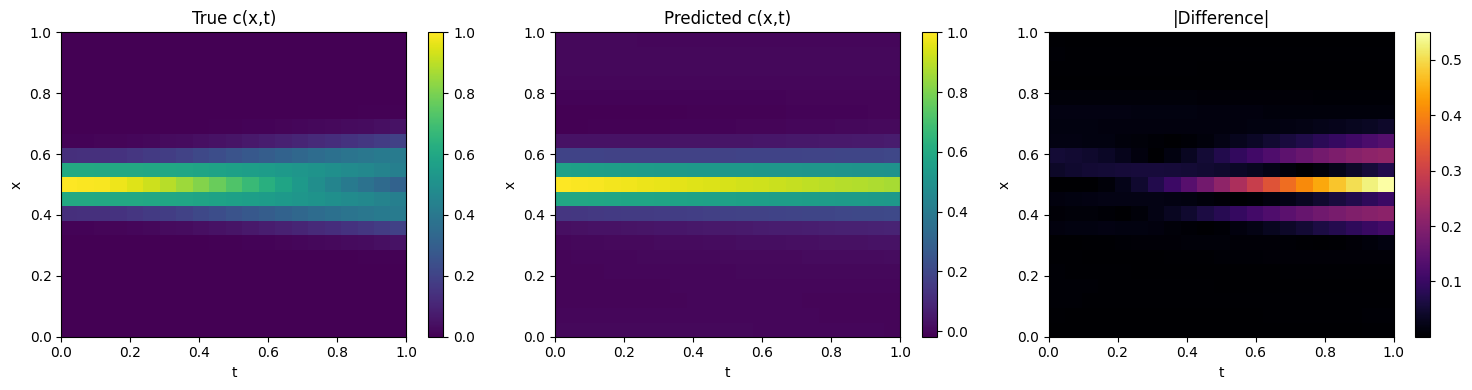

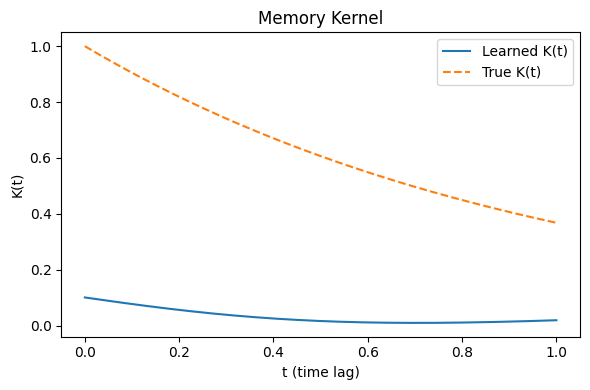

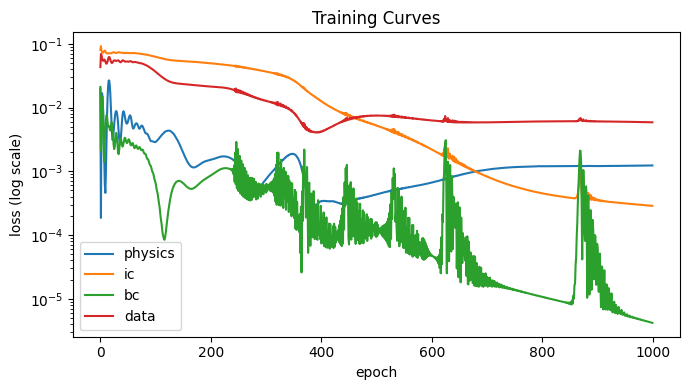

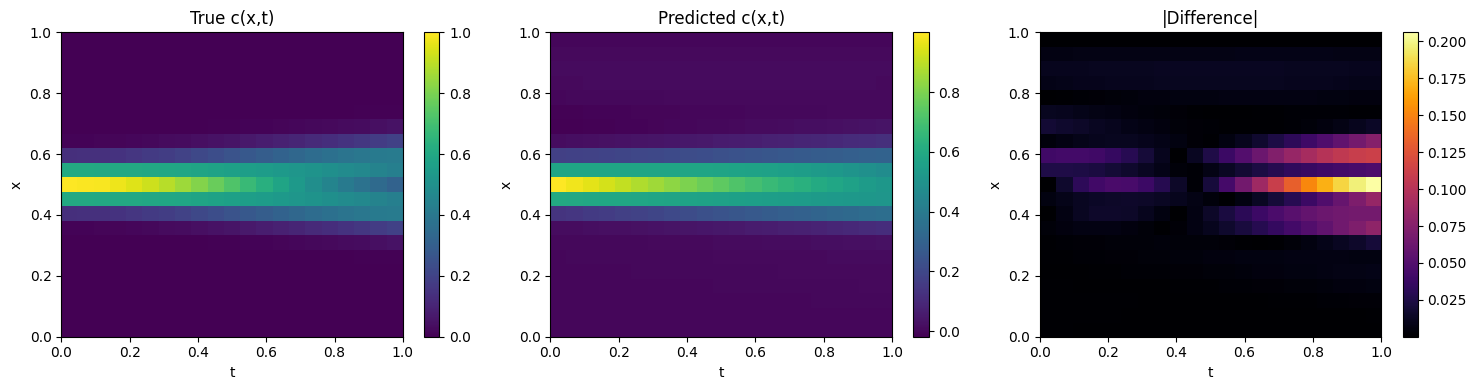

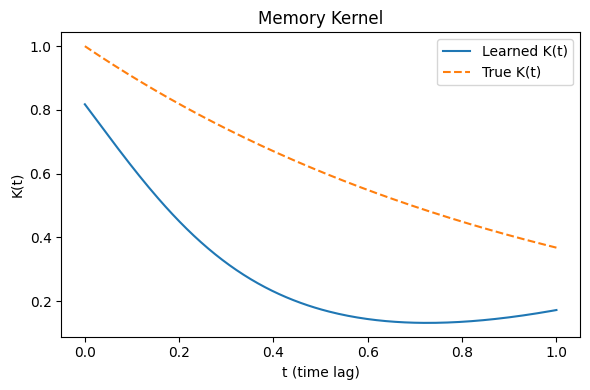

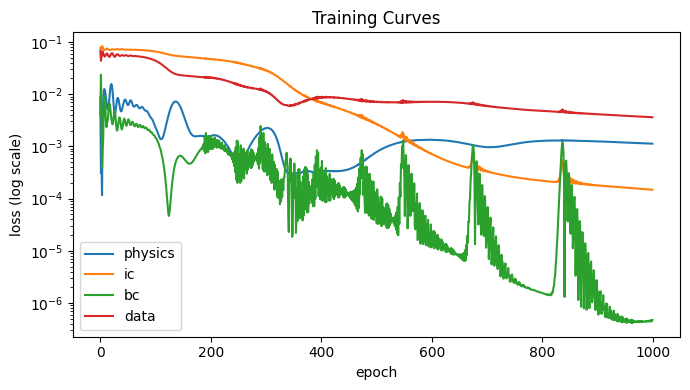

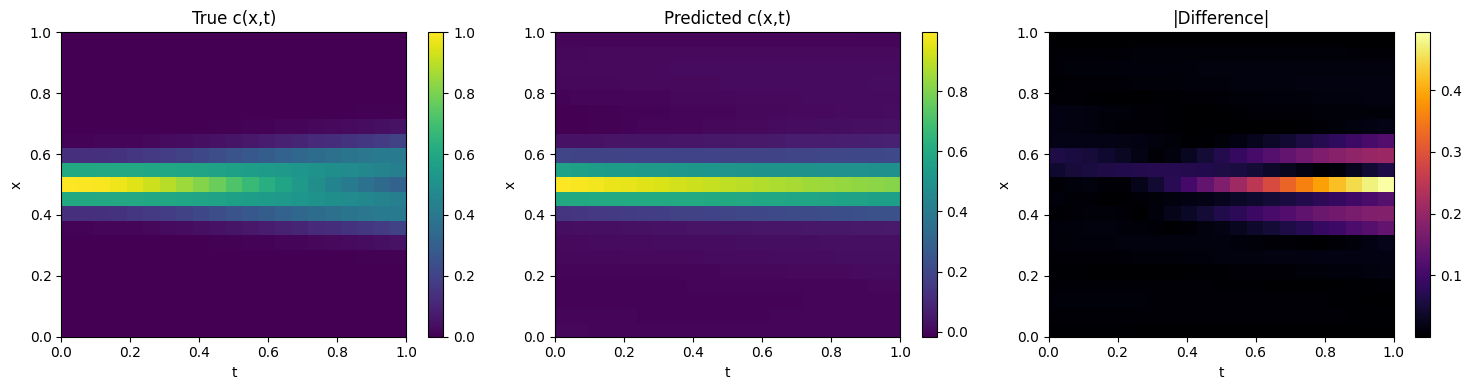

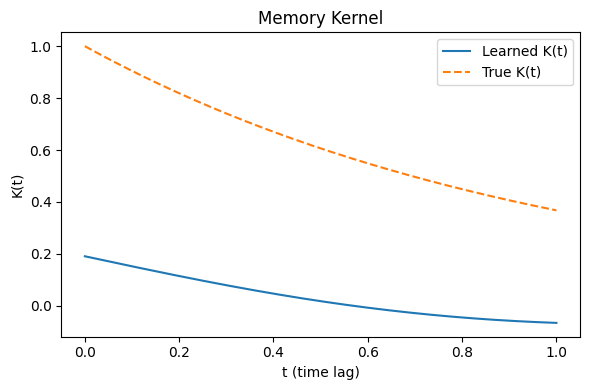

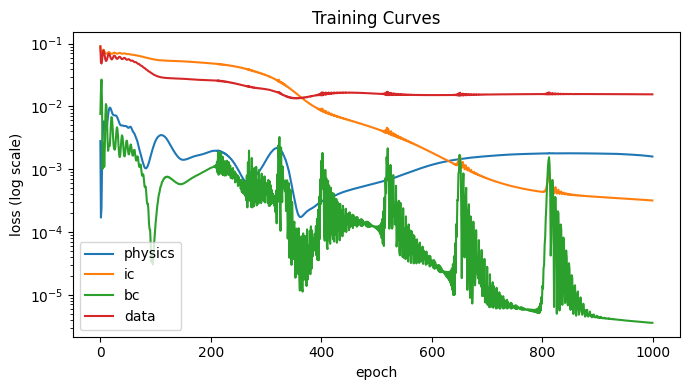

In [11]:
noise_levels = [0.01, 0.05, 0.10]
exp4_results = []

for noise in noise_levels:
    name = f"exp4_noise_{int(noise*100)}pct"
    res, _, _ = run_experiment(name, learn_kernel=True, obs_fraction=0.10,
                                noise_std=noise, **DEMO_KW)
    exp4_results.append(res)


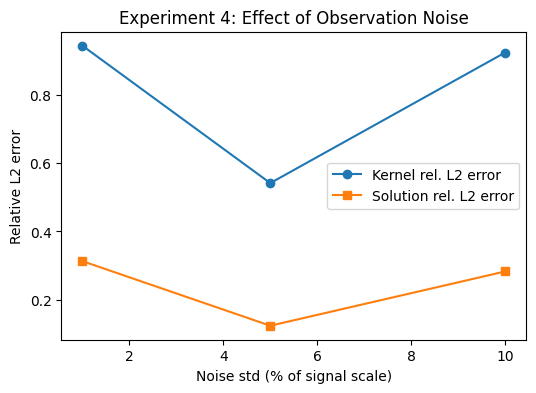

In [12]:
kernel_errs = [r['kernel_rel_l2'] for r in exp4_results]
sol_errs = [r['relative_l2'] for r in exp4_results]

fig, ax = plt.subplots(figsize=(6,4))
ax.plot([n*100 for n in noise_levels], kernel_errs, 'o-', label='Kernel rel. L2 error')
ax.plot([n*100 for n in noise_levels], sol_errs, 's-', label='Solution rel. L2 error')
ax.set_xlabel('Noise std (% of signal scale)')
ax.set_ylabel('Relative L2 error')
ax.set_title('Experiment 4: Effect of Observation Noise')
ax.legend()
plt.savefig('../results/exp4_summary.png', dpi=150)
plt.show()


## Summary

| Experiment | Setting | Solution rel. L2 | Kernel rel. L2 |
|---|---|---|---|
| 1 | Known kernel | see above | n/a (fixed) |
| 2 | Unknown kernel, 20% data | see above | see above |
| 3 | Sparsity sweep (20% -> 1%) | plotted above | plotted above |
| 4 | Noise sweep (1% -> 10%) | plotted above | plotted above |

**Takeaways to look for:**
- The memory residual + trapezoidal quadrature reproduce the FD ground
  truth reasonably well when the kernel is known (Experiment 1).
- Jointly learning the kernel is harder but tractable with enough data
  (Experiment 2).
- As observations become sparser, the learned kernel typically degrades
  faster than the solution field itself, since the kernel is only
  identifiable through its effect on the (already smooth) diffusion
  process (Experiment 3).
- Noise primarily hurts the data-fit term; with fixed loss weights the
  model may overfit noise at high noise levels unless training is
  stopped early or weights are retuned (Experiment 4).

This project intentionally used small grids, full-batch training, and
simple trapezoidal quadrature -- see the README for how to scale things up
for higher accuracy.
